
<img src="https://weclouddata.s3.amazonaws.com/images/logos/wcd_logo_new_2.png" width='30%'>

<h1 align="left"> ML Workflow 101 </h1>
Delivered by WeCloudData
<br>

----------

> Please note that this is a very simple example of ML workflow. The purpose is for students to have an overview of the entire process at the beginning of the course. We will dive in and expand on each step to learn the tecniques in more depth.

# $\Omega$ Machine Learning Introduction

> Scikit-learn (formerly scikits.learn) is a free software machine learning library for the Python programming language. It features various classification, regression and clustering algorithms including support vector machines, random forests, gradient boosting, k-means and DBSCAN, and is designed to interoperate with the Python numerical and scientific libraries NumPy and SciPy.

http://scikit-learn.org/stable/user_guide.html

## ML Explained


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from mlxtend.plotting import category_scatter
from mlxtend.plotting import plot_decision_regions

%matplotlib inline

In [ ]:
X, y = make_blobs(centers=[[1, 1], [2, 2]], random_state=1)

df = pd.DataFrame(X, columns=['feature1', 'feature2']).assign(label=y)

df.head()

,feature1,feature2,label
0,0.471828,-0.072969,0
1,1.889553,1.382638,1
2,2.520576,0.855659,1
3,1.819080,1.396079,1
4,4.190700,0.103639,1


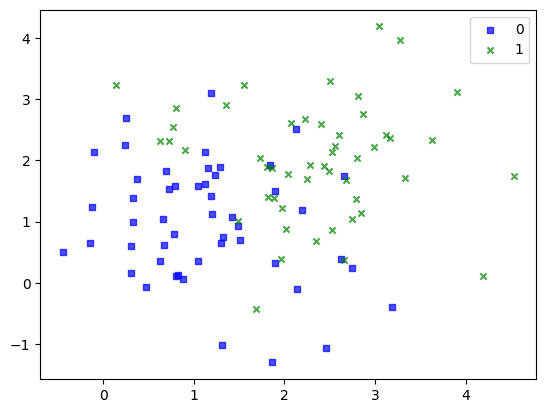

In [ ]:
category_scatter(x='feature1', y='feature2', label_col='label', data=df);

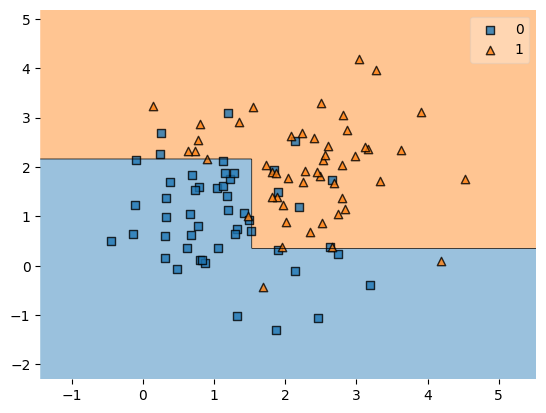

In [ ]:
d_tree = DecisionTreeClassifier(max_depth=2)
d_tree.fit(X, y)

plot_decision_regions(X, y, clf=d_tree);

## Titanic

In [ ]:
titanic = pd.read_csv('https://weclouddata.s3.amazonaws.com/data/titanic.csv')

In [ ]:
titanic.head(3)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


### Data Exploration

In [ ]:
titanic.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1308.000000,1308.000000,1045.000000,1308.000000,1308.000000,1308.000000,120.000000
mean,2.294343,0.382263,29.851834,0.499235,0.385321,33.295479,159.975000
std,0.837929,0.486126,14.389201,1.041965,0.865826,51.758668,97.672103
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,71.500000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,154.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,255.250000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


<Axes: >

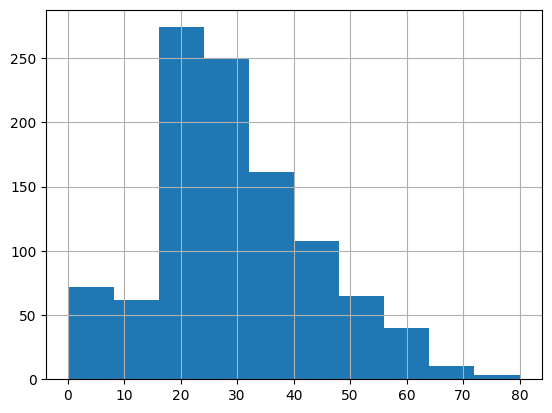

In [ ]:
titanic['age'].hist()

<Axes: >

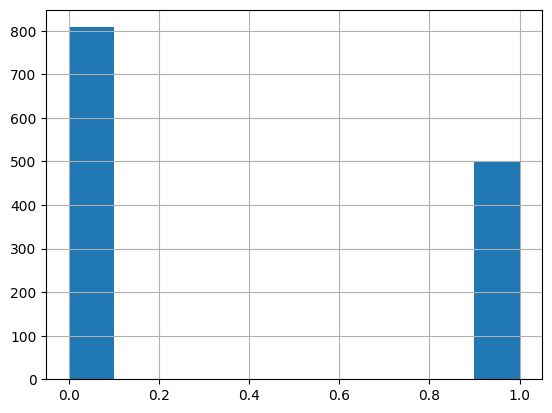

In [ ]:
titanic['survived'].hist()

### Missing Value Handling

In [ ]:
titanic.isnull().sum()

,0
pclass,0
survived,0
name,0
sex,0
age,263
sibsp,0
parch,0
ticket,0
fare,0
cabin,1013


In [ ]:
mean_age = titanic['age'].mean()

mean_age

np.float64(29.851834162679427)

In [ ]:
# Imputation

titanic['age'] = titanic['age'].fillna(mean_age)

In [ ]:
titanic.isnull().sum()

,0
pclass,0
survived,0
name,0
sex,0
age,0
sibsp,0
parch,0
ticket,0
fare,0
cabin,1013


### Selecting features

In [ ]:
features = ['pclass', 'age', 'fare', 'sibsp']

### Make feature dataset

In [ ]:
X = titanic[features]

### Make label

In [ ]:
y = titanic['survived']

### Make validation dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
X_train.shape

(876, 4)

In [ ]:
X_test.shape

(432, 4)

In [ ]:
y_train.shape

(876,)

In [ ]:
y_test.shape

(432,)

### Build/train model

In [ ]:
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

DecisionTreeClassifier()

### Model prediction

In [ ]:
y_pred = model.predict(X_test)

### Model evaluation

In [ ]:
accuracy_score(y_test, y_pred)

0.6527777777777778

### Variable Importance

In [ ]:
model.feature_importances_

array([0.04171613, 0.36846142, 0.50883572, 0.08098672])

In [ ]:
list(zip(features, model.feature_importances_))

[('pclass', np.float64(0.041716128208724744)),
 ('age', np.float64(0.36846142353628636)),
 ('fare', np.float64(0.5088357237495875)),
 ('sibsp', np.float64(0.08098672450540136))]

In [ ]:
important_features = pd.DataFrame(list(zip(features, model.feature_importances_)),
                                  columns=['feature', 'importance'])

In [ ]:
important_features.set_index('feature', inplace=True)

<Axes: ylabel='feature'>

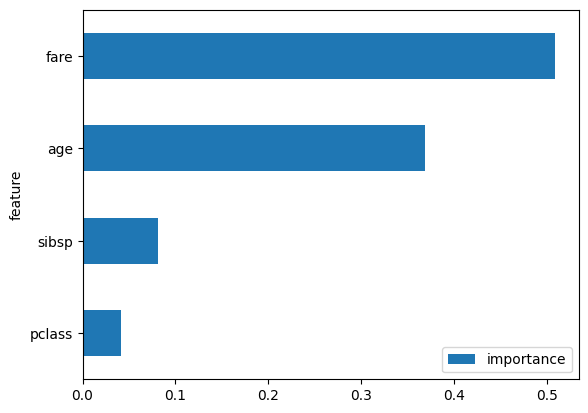

In [ ]:
important_features.sort_values(by='importance').plot(kind='barh')